In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from collections import defaultdict
import matplotlib.ticker as ticker
import glob
import os
import pickle
import sys
sys.path.append("/scratch/halmazan//WCTE/WCTECoincidence_Analysis/Complete_analysis")

import candidate_plots

from matplotlib import rcParams
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [10, 8]
rcParams['font.size'] = 22

In [2]:
#Runs to compare 
sig_run = ['2385', '2386'] # 2389
pos = [0.0, 0.0, -30.5]
bkg_run = '2384'

N_events_sig = 75703 + 109982 # 101923
N_events_bkg = 157893

prompt_window = 1500  # Window for prompt candidates
prompt_dead_time = 200  # Death time for prompt candidates
prompt_t_rms_min = 200
prompt_t_rms_max = 400
prompt_nhits_min = 150
prompt_nhits_max = 300
coincidence_window = 150000  # Window for coincidence search
delayed_window = 100  # Window for delayed candidates
delayed_nhits_min = 10  # Minimum number of hits for delayed candidates
delayed_nhits_max = 30  # Maximum number of hits for delayed candidates

In [3]:
bkg_file = f'/scratch/halmazan/WCTE/files/data/AmBeCandidates/neutron_candidates_{bkg_run}_timestest.csv'
df_bkg = pd.read_csv(bkg_file)
df_array = []

for run in sig_run:
    sig_file = f'/scratch/halmazan/WCTE/files/data/AmBeCandidates/neutron_candidates_{run}_timestest.csv'
    df_array.append(pd.read_csv(sig_file))

df = pd.concat(df_array, ignore_index=True, sort=False)

candidate_plots.deltaR_to_fixed(df, pos)
candidate_plots.deltaR_to_fixed(df_bkg, pos)

candidate_plots.deltaT(df)
candidate_plots.deltaT(df_bkg)

In [4]:
df = df.sort_values(['prompt_time', 'prompt_nhits']).reset_index(drop=True)
df['prompt_id'] = df.groupby(['prompt_nhits', 'prompt_time'], sort=False).ngroup()
df['delayed_id'] = df.groupby(['prompt_nhits', 'prompt_time'], sort=False).cumcount()
cols = ['prompt_id', 'delayed_id'] + [col for col in df.columns if col not in ['prompt_id', 'delayed_id']]
df = df[cols]

df_bkg = df_bkg.sort_values(['prompt_time', 'prompt_nhits']).reset_index(drop=True)
df_bkg['prompt_id'] = df_bkg.groupby(['prompt_nhits', 'prompt_time'], sort=False).ngroup()
df_bkg['delayed_id'] = df_bkg.groupby(['prompt_nhits', 'prompt_time'], sort=False).cumcount()
cols = ['prompt_id', 'delayed_id'] + [col for col in df_bkg.columns if col not in ['prompt_id', 'delayed_id']]
df_bkg = df_bkg[cols]

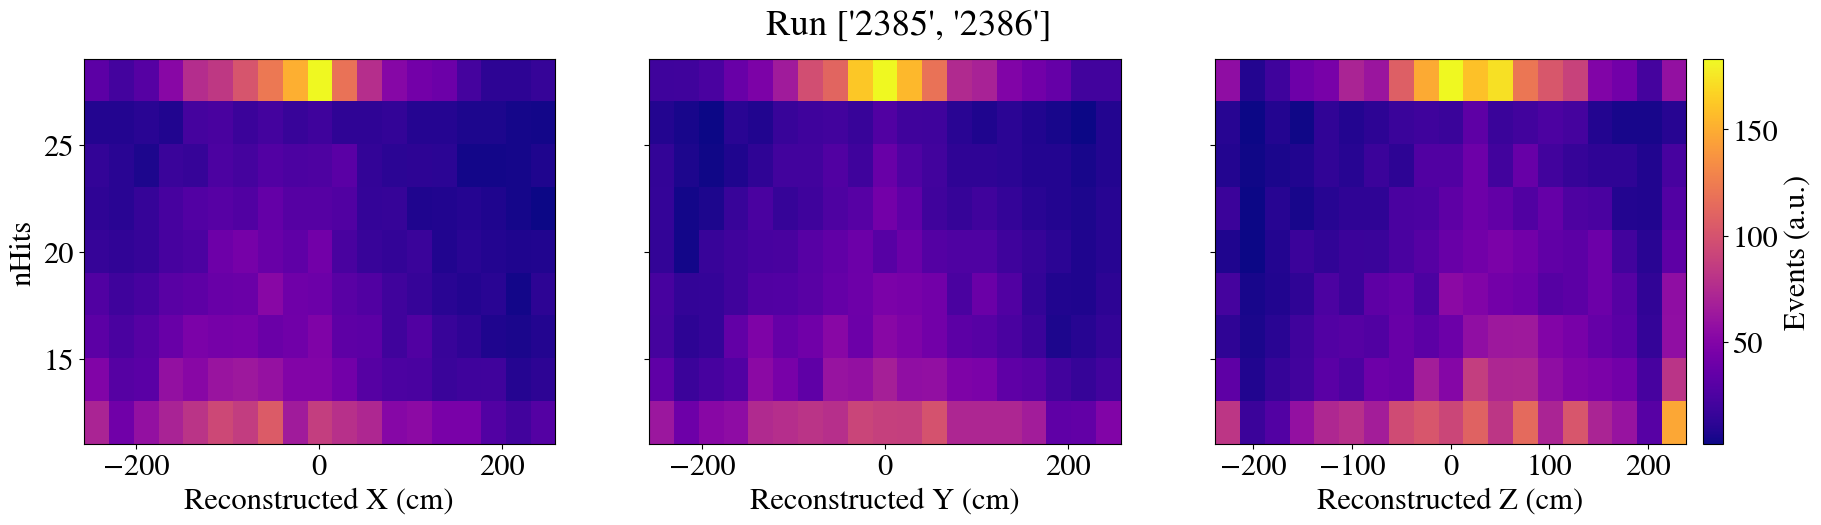

In [5]:
candidate_plots.pl_nHits_pos(df, sig_run)

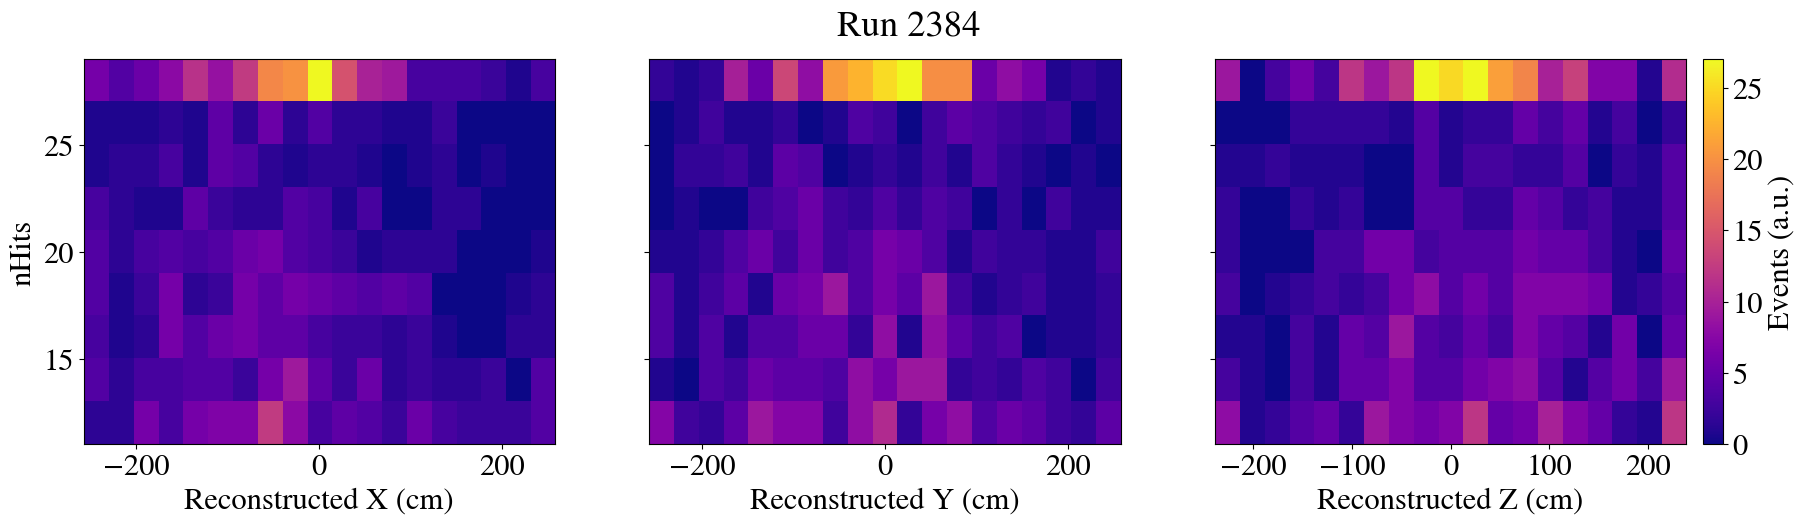

In [6]:
candidate_plots.pl_nHits_pos(df_bkg, bkg_run)

In [7]:
N_events_sel_sig = len(df["prompt_id"])
N_events_sel_bkg = len(df_bkg["prompt_id"])  #df_bkg["event_number"].nunique() 

print("Events Signal", N_events_sel_sig)
print("Events Bkg", N_events_sel_bkg)

print("Signal Events/Second", N_events_sel_sig/(N_events_sig*270*1e-6))
print("Bkg Events/Second", N_events_sel_bkg/(N_events_bkg*270*1e-6))

print("Candidate events/Second", N_events_sel_sig/(N_events_sig*270*1e-6) - N_events_sel_bkg/(N_events_bkg*270*1e-6))

Events Signal 6578
Events Bkg 726
Signal Events/Second 131.20587534245072
Bkg Events/Second 17.029816957616163
Candidate events/Second 114.17605838483456


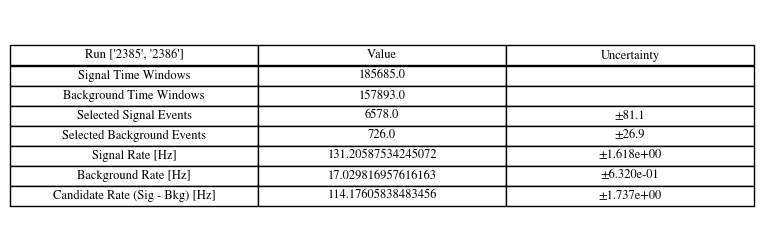

In [8]:
window_time = 270e-6  # seconds per time window

# --- Compute rates ---
rate_sig = N_events_sel_sig / (N_events_sig * window_time)
rate_bkg = N_events_sel_bkg / (N_events_bkg * window_time)
rate_diff = rate_sig - rate_bkg

# --- Statistical uncertainties ---
# Poisson error for counts
err_N_sig = np.sqrt(N_events_sel_sig)
err_N_bkg = np.sqrt(N_events_sel_bkg)

# propagate to rates: rate = N_sel / (N_total * window_time)
err_rate_sig = err_N_sig / (N_events_sig * window_time)
err_rate_bkg = err_N_bkg / (N_events_bkg * window_time)

# difference uncertainty (assuming independence)
err_rate_diff = np.sqrt(err_rate_sig**2 + err_rate_bkg**2)

# --- Create summary table ---
results = {
    f"Run {sig_run}": [
        "Signal Time Windows",
        "Background Time Windows",
        "Selected Signal Events",
        "Selected Background Events",
        "Signal Rate [Hz]",
        "Background Rate [Hz]",
        "Candidate Rate (Sig - Bkg) [Hz]",
    ],
    "Value": [
        N_events_sig,
        N_events_bkg,
        N_events_sel_sig,
        N_events_sel_bkg,
        rate_sig,
        rate_bkg,
        rate_diff,
    ],
    "Uncertainty": [
        "",  # time windows: no Poisson error
        "",
        f"±{err_N_sig:.1f}",
        f"±{err_N_bkg:.1f}",
        f"±{err_rate_sig:.3e}",
        f"±{err_rate_bkg:.3e}",
        f"±{err_rate_diff:.3e}",
    ]
}

df_results = pd.DataFrame(results)

# Show nicely
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,3))
ax.axis('off')
tbl = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.2)

plt.show()


In [9]:
df

,prompt_id,delayed_id,prompt_nhits,prompt_time,prompt_trms,prompt_x,prompt_y,prompt_z,delayed_time,delayed_nhits,delayed_x,delayed_y,delayed_z,DeltaR,DeltaT
0,0,0,168,4.340542e+09,225.621856,-52.486267,-57.820763,33.019642,4.340598e+09,29,-78.588394,28.571972,92.442528,148.685434,56.199398
1,0,1,168,4.340542e+09,225.621856,-52.486267,-57.820763,33.019642,4.340661e+09,11,-257.640717,-5.536000,102.941681,290.200049,119.799382
2,1,0,182,4.366118e+09,272.685753,-239.823013,94.309608,238.848557,4.366120e+09,24,-200.640289,56.619022,91.842842,241.723003,1.500276
3,1,1,182,4.366118e+09,272.685753,-239.823013,94.309608,238.848557,4.366121e+09,29,-255.182556,35.934021,113.713547,295.308208,2.709189
4,1,2,182,4.366118e+09,272.685753,-239.823013,94.309608,238.848557,4.366180e+09,29,-20.730085,50.754585,52.515587,99.485436,61.230351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6573,1760,0,195,1.345821e+12,247.079598,-137.899429,61.357273,89.869972,1.345821e+12,18,60.208515,-250.567993,238.848557,372.770746,100.932104
6574,1761,0,157,1.345841e+12,227.313122,15.948623,3.467802,190.783569,1.345841e+12,29,-160.072937,-91.505180,98.316521,224.922741,129.801440
6575,1762,0,187,1.345914e+12,211.270669,-3.103086,192.466690,-100.797546,1.345914e+12,29,73.386917,-49.968102,-73.463692,98.632295,22.306115
6576,1763,0,228,1.345936e+12,212.588350,-175.303589,125.710449,179.607178,1.345936e+12,17,-80.769676,155.726608,36.335182,187.727086,5.500977


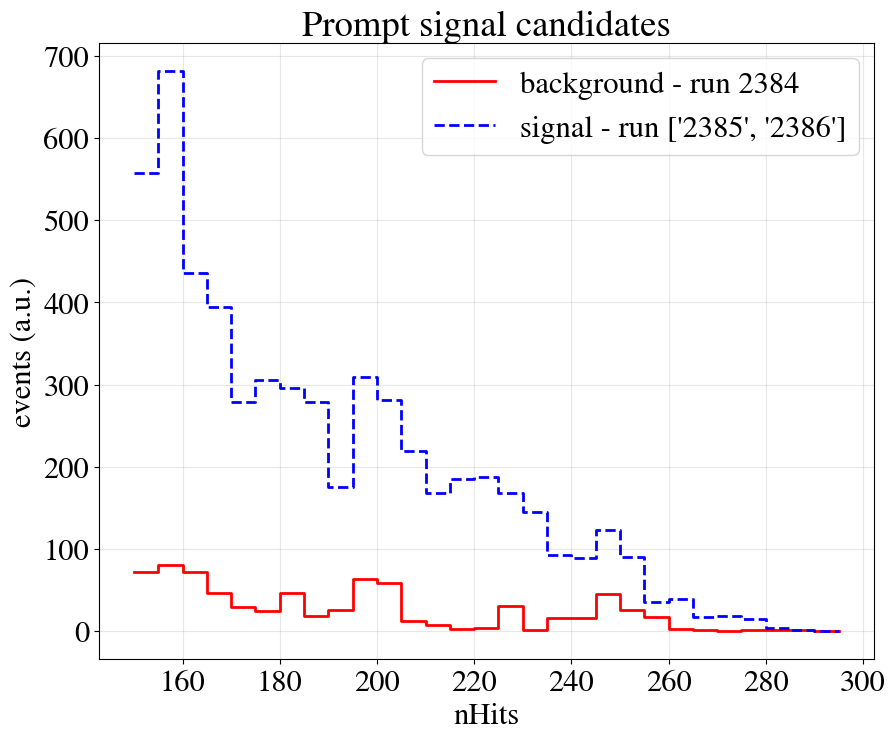

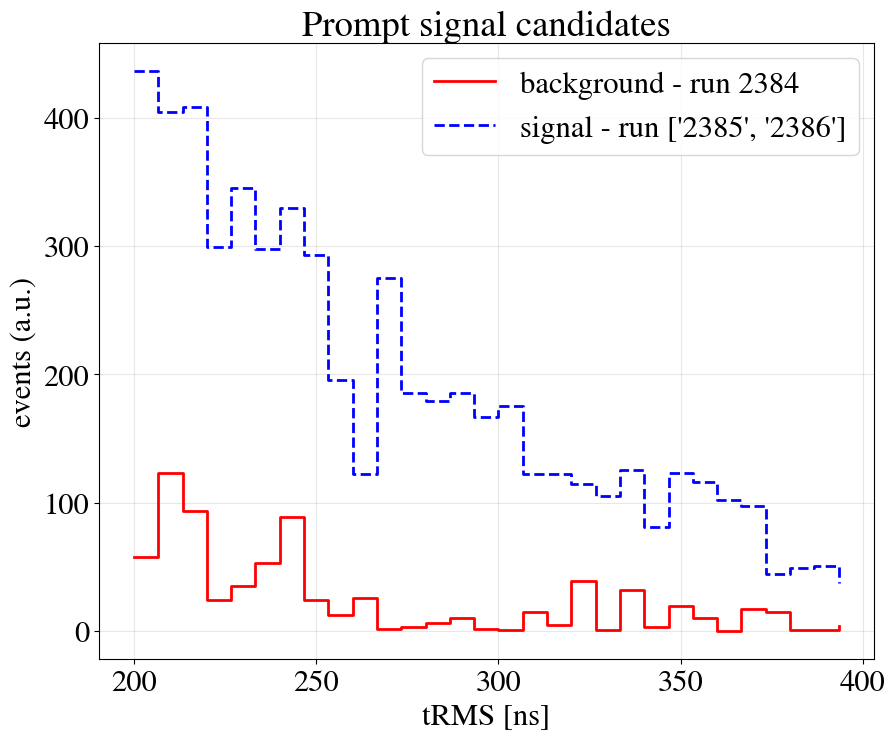

In [10]:
candidate_plots.pl_prompt(N_events_bkg, N_events_sig, df, df_bkg, sig_run, bkg_run, prompt_nhits_min, prompt_nhits_max, prompt_t_rms_min, prompt_t_rms_max)

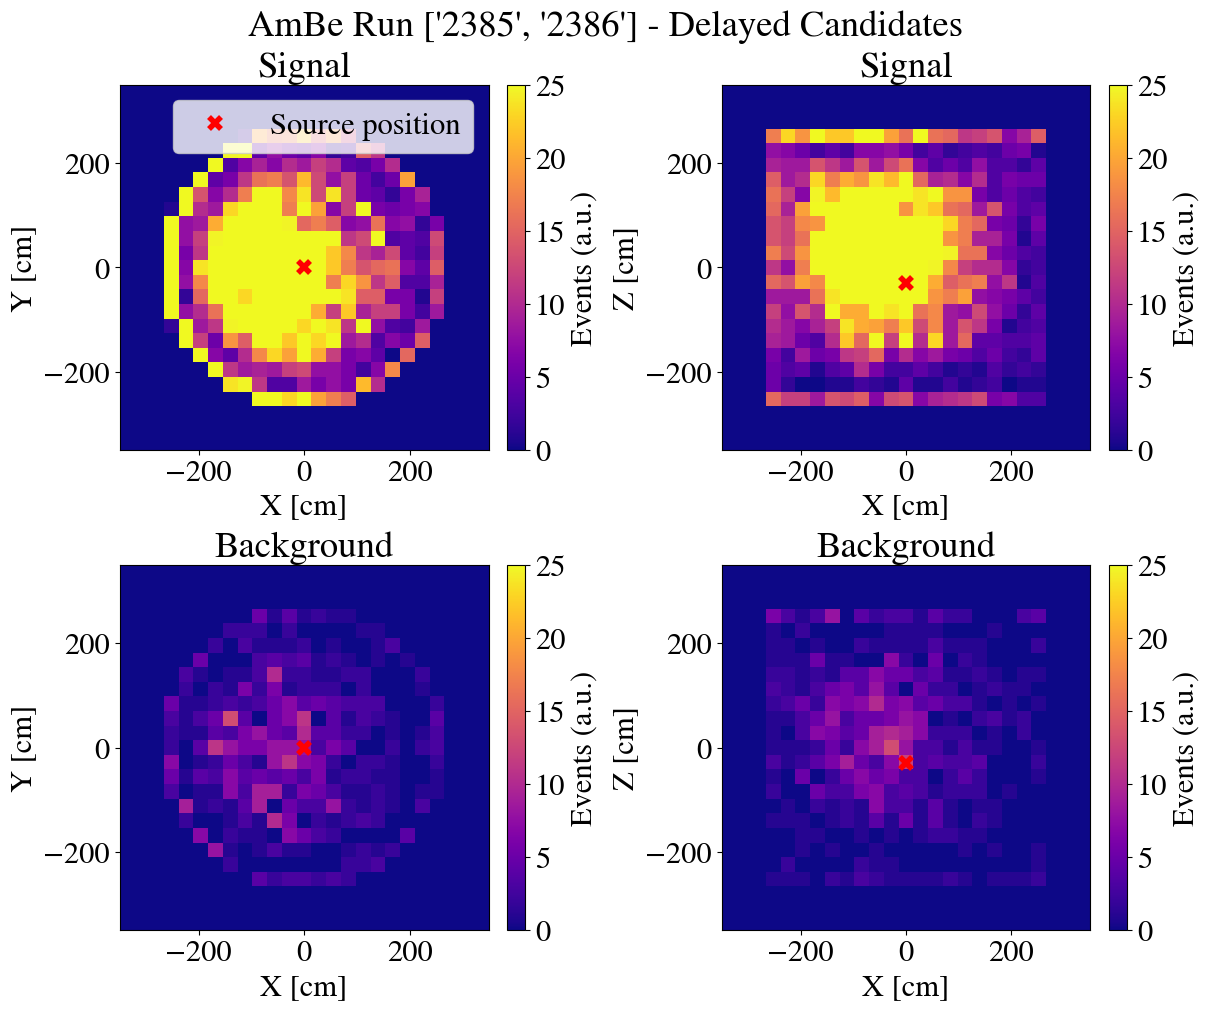

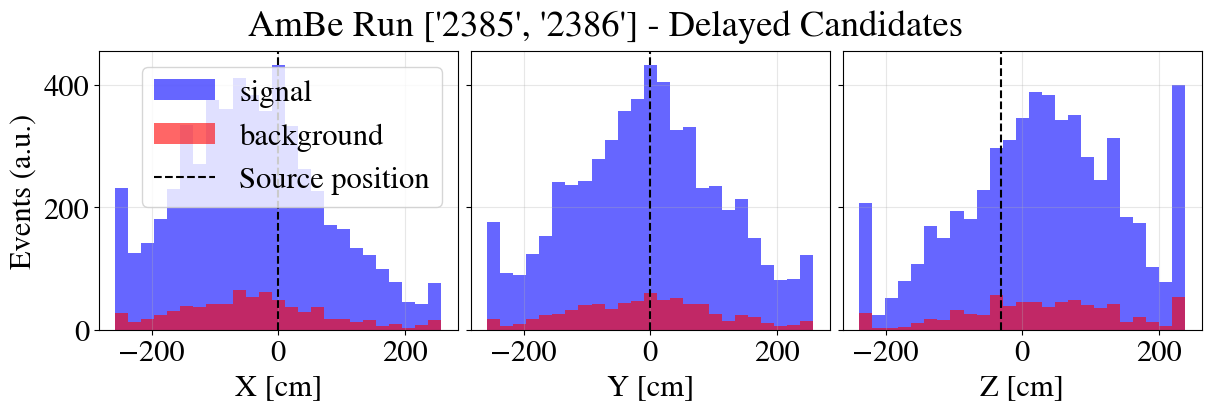

In [11]:
candidate_plots.pl_bonsai(N_events_bkg, N_events_sig, df, df_bkg, pos, sig_run)

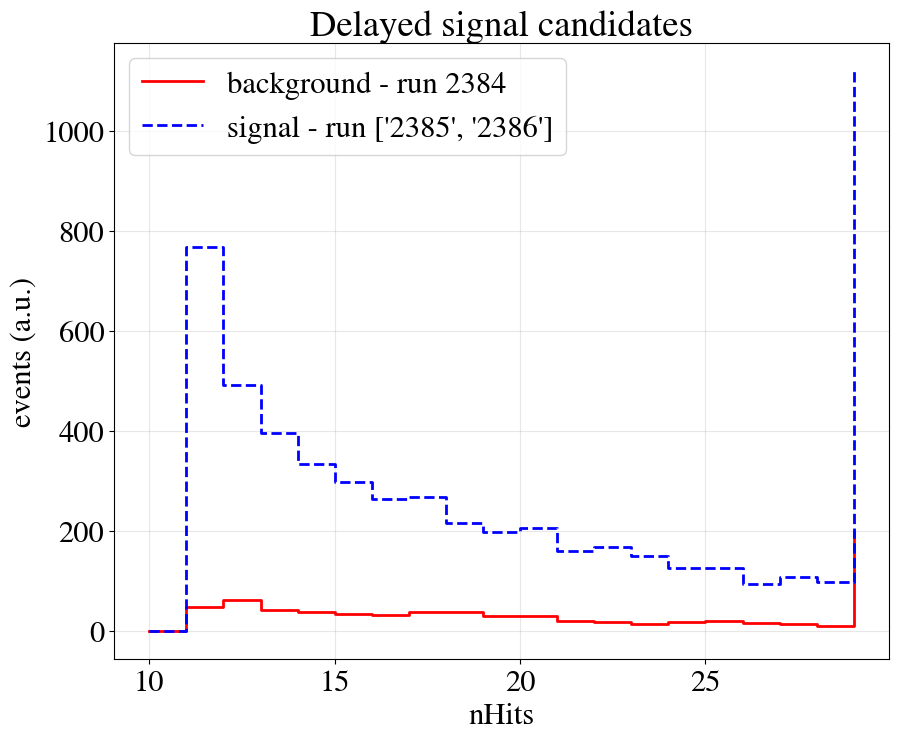

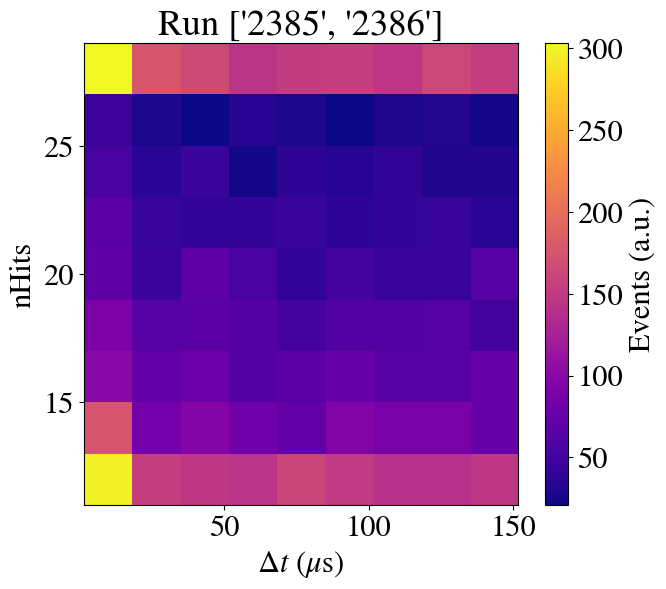

In [12]:
candidate_plots.pl_delayed(N_events_bkg, N_events_sig, df, df_bkg, sig_run, bkg_run, delayed_nhits_min, delayed_nhits_max)

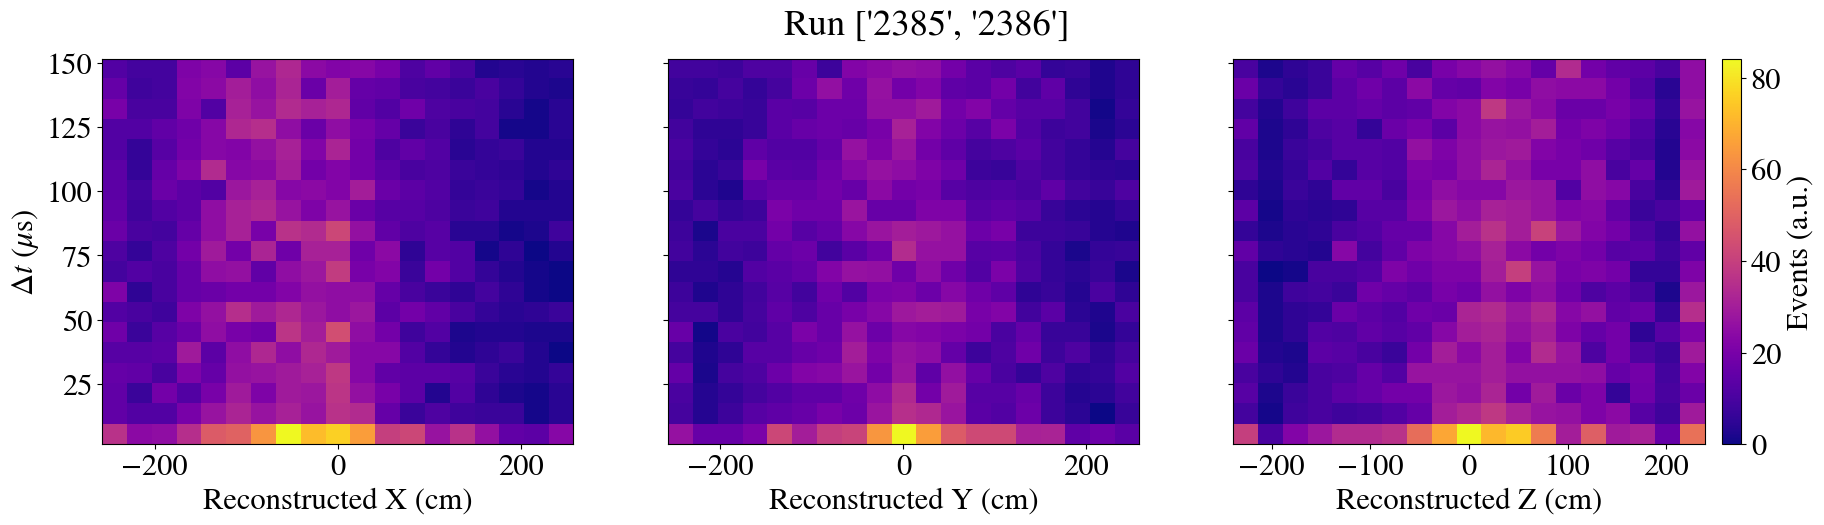

In [13]:
candidate_plots.pl_deltaT_pos(df, sig_run)

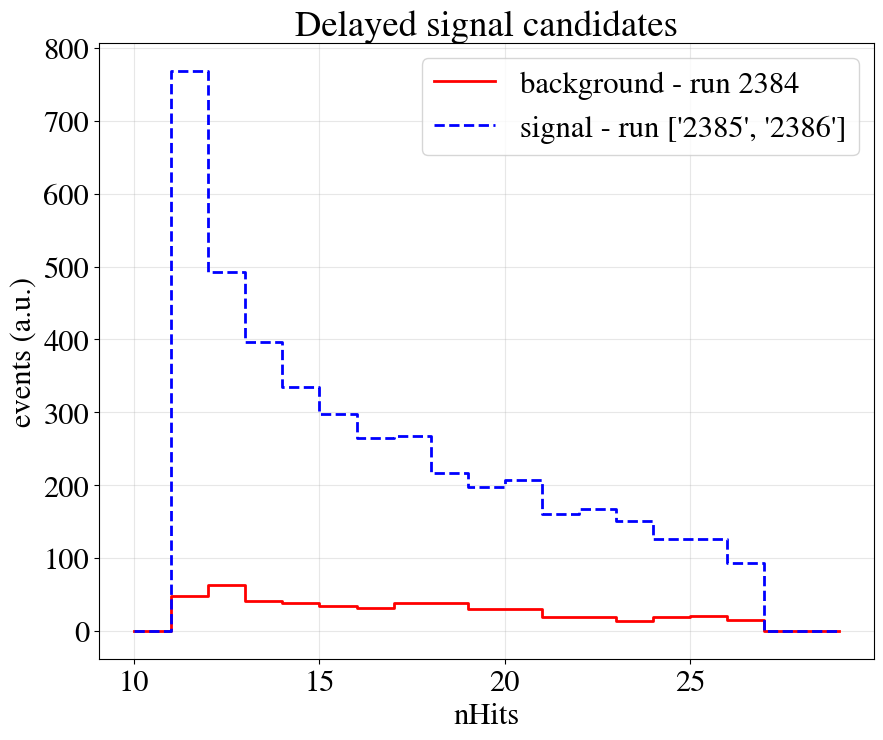

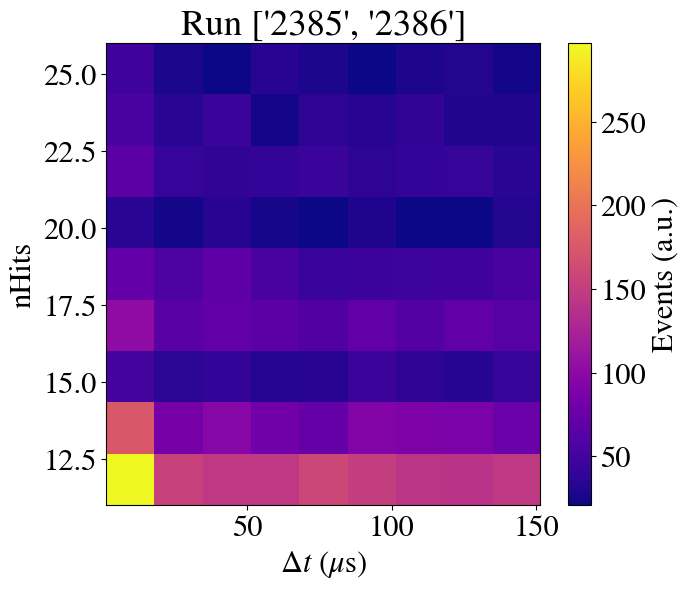

In [14]:
df = df[(df['delayed_nhits'] < 27)]
df_bkg = df_bkg[(df_bkg['delayed_nhits'] < 27)]

candidate_plots.pl_delayed(N_events_bkg, N_events_sig, df, df_bkg, sig_run, bkg_run, delayed_nhits_min, delayed_nhits_max)

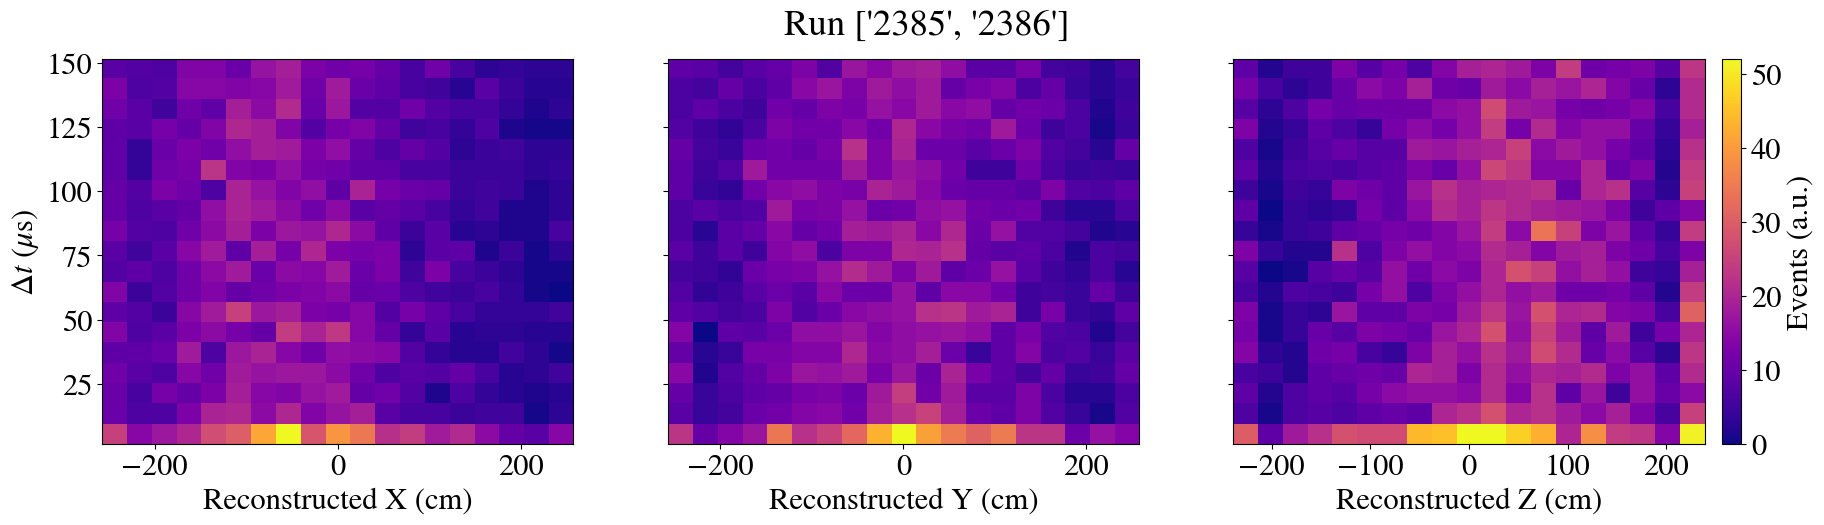

In [15]:
candidate_plots.pl_deltaT_pos(df, sig_run)

In [16]:
df

,prompt_id,delayed_id,prompt_nhits,prompt_time,prompt_trms,prompt_x,prompt_y,prompt_z,delayed_time,delayed_nhits,delayed_x,delayed_y,delayed_z,DeltaR,DeltaT
1,0,1,168,4.340542e+09,225.621856,-52.486267,-57.820763,33.019642,4.340661e+09,11,-257.640717,-5.536000,102.941681,290.200049,119.799382
2,1,0,182,4.366118e+09,272.685753,-239.823013,94.309608,238.848557,4.366120e+09,24,-200.640289,56.619022,91.842842,241.723003,1.500276
5,2,0,198,4.369628e+09,224.715119,106.730202,110.559296,83.451988,4.369723e+09,20,128.896469,-61.085957,-138.782364,179.083400,94.894835
7,4,0,255,4.420264e+09,258.414558,-220.527313,-133.330780,217.992126,4.420266e+09,18,257.515686,-9.749803,238.848557,372.770750,1.500848
8,5,0,185,4.423303e+09,215.388965,-103.202858,55.094444,143.439789,4.423322e+09,11,67.013031,-248.834564,-238.848557,331.388756,19.650091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6569,1757,1,151,1.345575e+12,330.691510,111.902412,-123.559036,96.227776,1.345575e+12,22,39.469021,38.259827,109.850037,150.730723,147.414826
6572,1759,1,158,1.345804e+12,215.877825,-30.043184,-173.318970,-186.419388,1.345804e+12,11,-144.423355,52.368881,7.783207,158.323116,51.752642
6573,1760,0,195,1.345821e+12,247.079598,-137.899429,61.357273,89.869972,1.345821e+12,18,60.208515,-250.567993,238.848557,372.770746,100.932104
6576,1763,0,228,1.345936e+12,212.588350,-175.303589,125.710449,179.607178,1.345936e+12,17,-80.769676,155.726608,36.335182,187.727086,5.500977


In [17]:
#idx = df.groupby(['prompt_id'])['delayed_nhits'].idxmax()
#idx = df.groupby(['prompt_id'])['DeltaR'].idxmin()
idx = df.groupby(['prompt_id'])['delayed_id'].idxmin()
df_filtered = df.loc[idx].reset_index(drop=True)
#df = df_filtered

#idx_bkg = df_bkg.groupby(['prompt_id'])['delayed_nhits'].idxmax()
#idx_bkg = df_bkg.groupby(['prompt_id'])['DeltaR'].idxmin()
idx_bkg = df_bkg.groupby(['prompt_id'])['delayed_id'].idxmin()
df_filtered_bkg = df_bkg.loc[idx_bkg].reset_index(drop=True)
#df_bkg = df_filtered_bkg

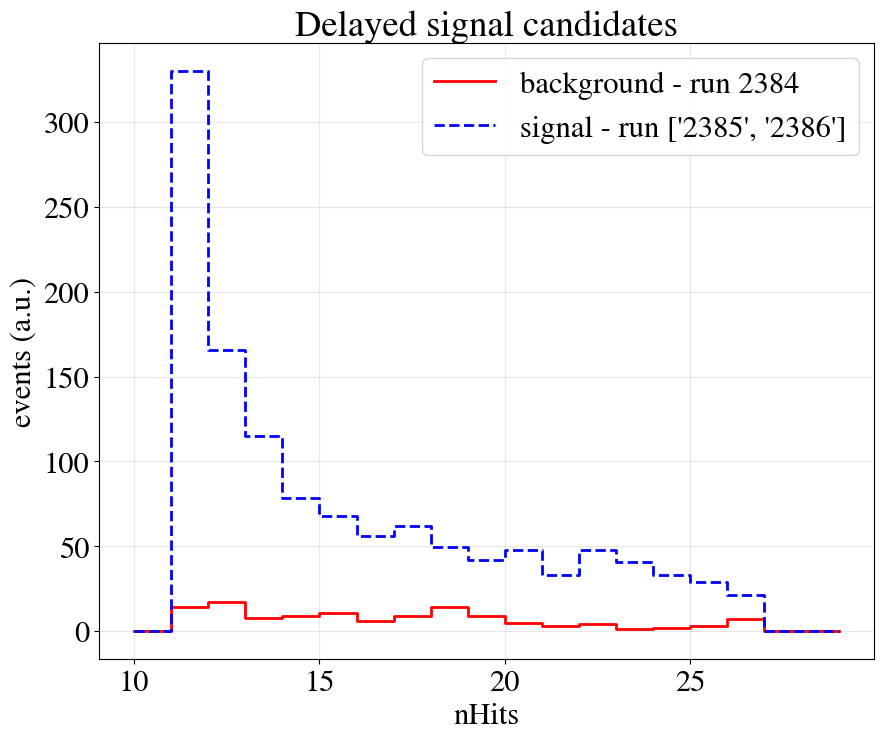

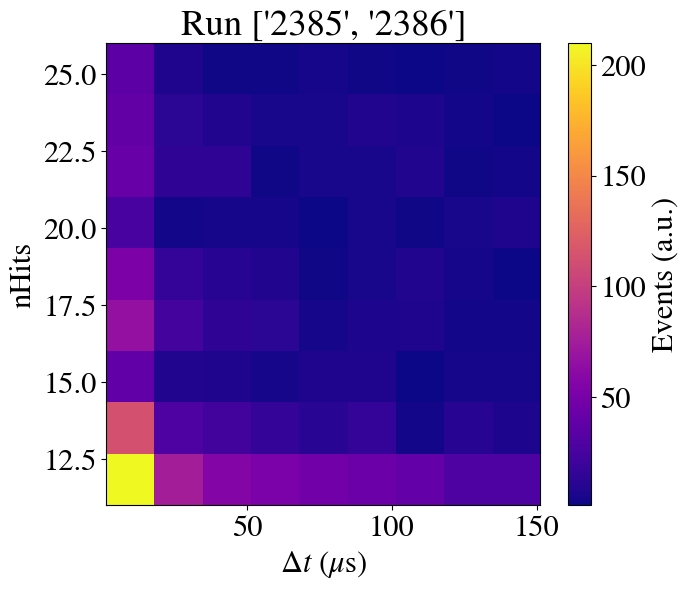

In [18]:
candidate_plots.pl_delayed(N_events_bkg, N_events_sig, df_filtered, df_filtered_bkg, sig_run, bkg_run, delayed_nhits_min, delayed_nhits_max)

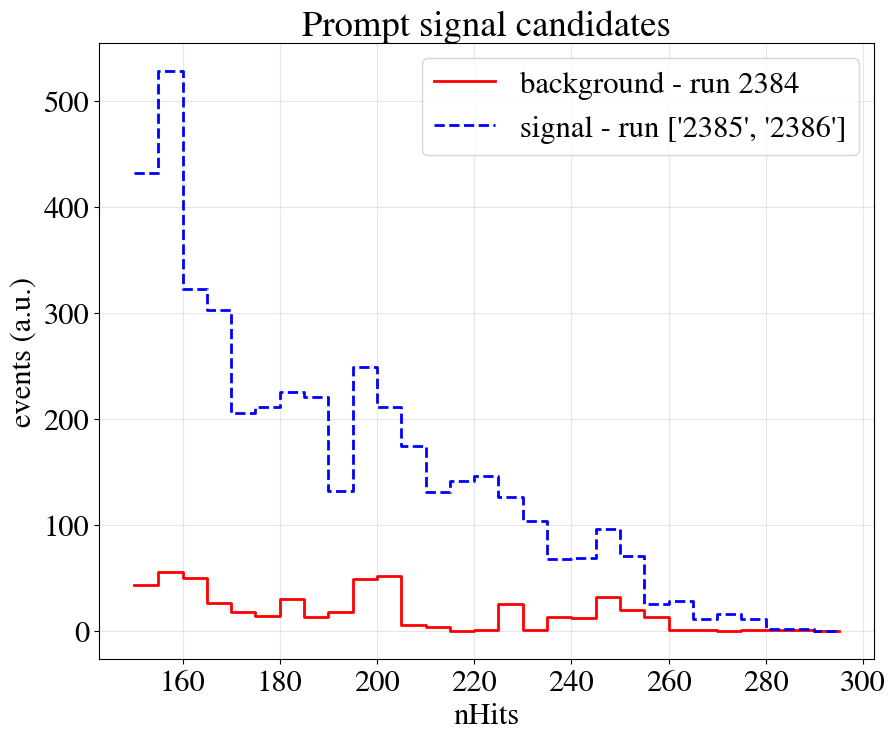

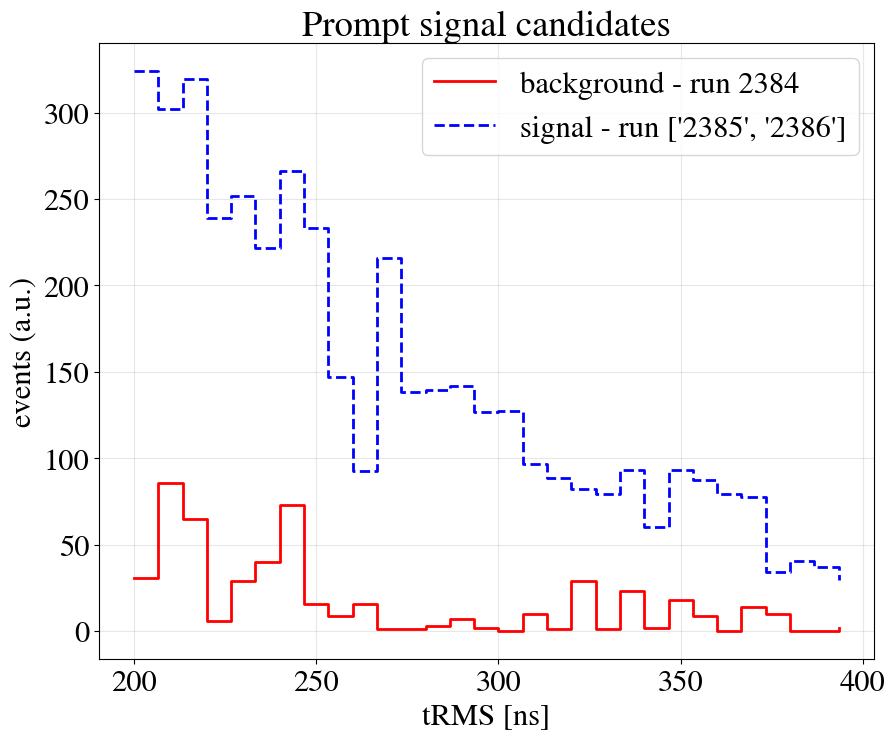

In [19]:
candidate_plots.pl_prompt(N_events_bkg, N_events_sig, df, df_bkg, sig_run, bkg_run, prompt_nhits_min, prompt_nhits_max, prompt_t_rms_min, prompt_t_rms_max)

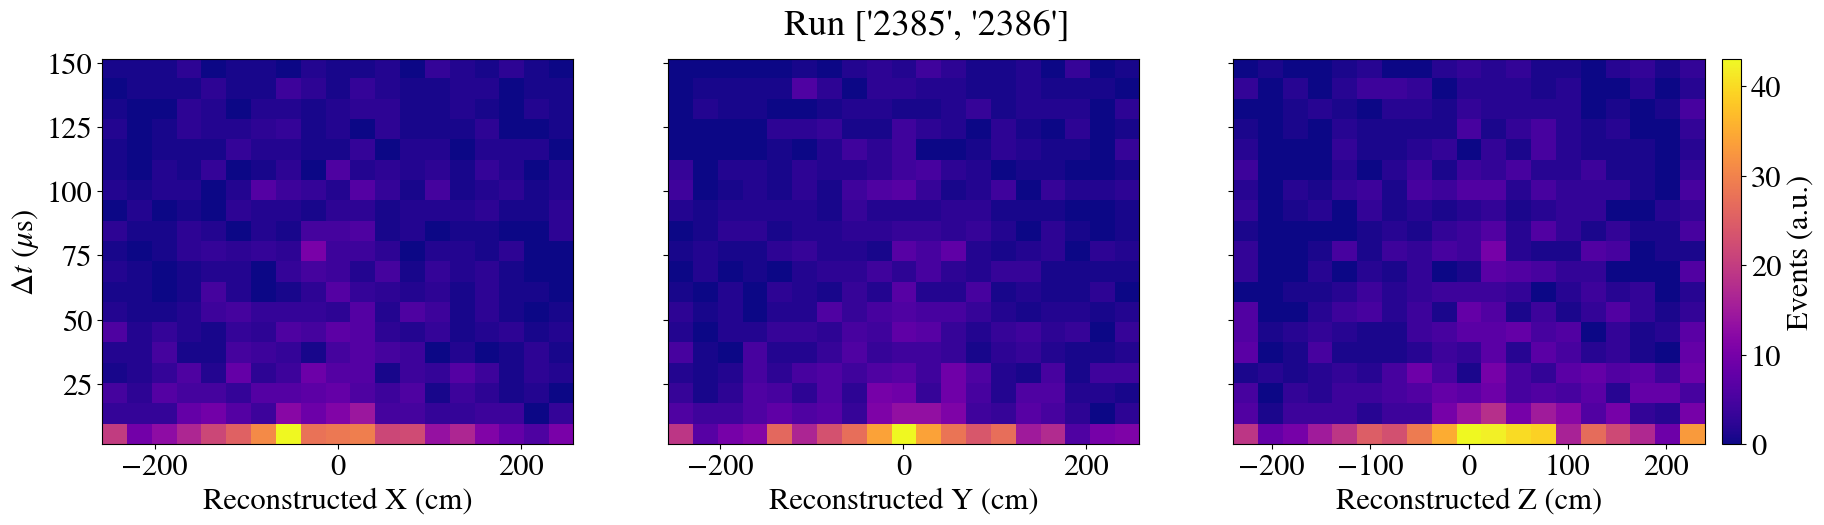

In [20]:
candidate_plots.pl_deltaT_pos(df_filtered, sig_run)

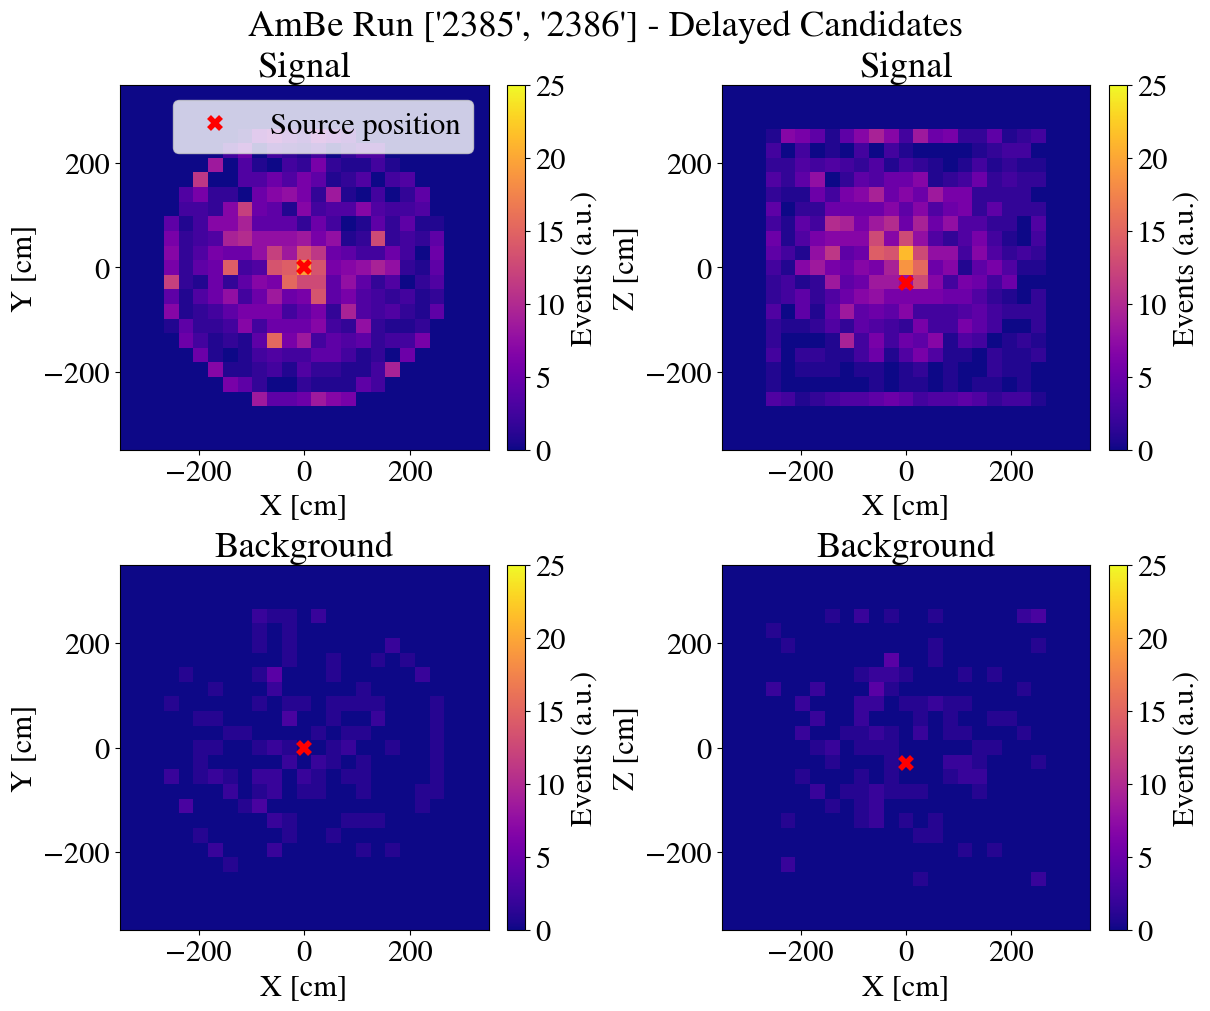

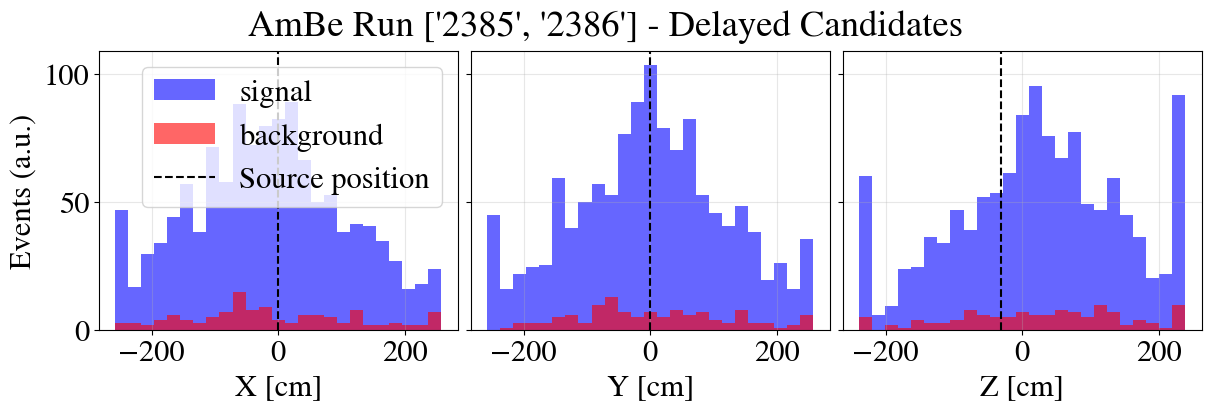

In [21]:
candidate_plots.pl_bonsai(N_events_bkg, N_events_sig, df_filtered, df_filtered_bkg, pos, sig_run)

In [22]:
df_filtered

,prompt_id,delayed_id,prompt_nhits,prompt_time,prompt_trms,prompt_x,prompt_y,prompt_z,delayed_time,delayed_nhits,delayed_x,delayed_y,delayed_z,DeltaR,DeltaT
0,0,1,168,4.340542e+09,225.621856,-52.486267,-57.820763,33.019642,4.340661e+09,11,-257.640717,-5.536000,102.941681,290.200049,119.799382
1,1,0,182,4.366118e+09,272.685753,-239.823013,94.309608,238.848557,4.366120e+09,24,-200.640289,56.619022,91.842842,241.723003,1.500276
2,2,0,198,4.369628e+09,224.715119,106.730202,110.559296,83.451988,4.369723e+09,20,128.896469,-61.085957,-138.782364,179.083400,94.894835
3,4,0,255,4.420264e+09,258.414558,-220.527313,-133.330780,217.992126,4.420266e+09,18,257.515686,-9.749803,238.848557,372.770750,1.500848
4,5,0,185,4.423303e+09,215.388965,-103.202858,55.094444,143.439789,4.423322e+09,11,67.013031,-248.834564,-238.848557,331.388756,19.650091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1428,1756,0,175,1.345574e+12,266.609012,160.746964,-44.259621,66.928543,1.345574e+12,20,-17.799089,-18.528854,31.236534,66.869467,1.500211
1429,1757,0,151,1.345575e+12,330.691510,111.902412,-123.559036,96.227776,1.345575e+12,11,21.503605,-256.801453,-127.970863,275.517622,102.930599
1430,1759,1,158,1.345804e+12,215.877825,-30.043184,-173.318970,-186.419388,1.345804e+12,11,-144.423355,52.368881,7.783207,158.323116,51.752642
1431,1760,0,195,1.345821e+12,247.079598,-137.899429,61.357273,89.869972,1.345821e+12,18,60.208515,-250.567993,238.848557,372.770746,100.932104


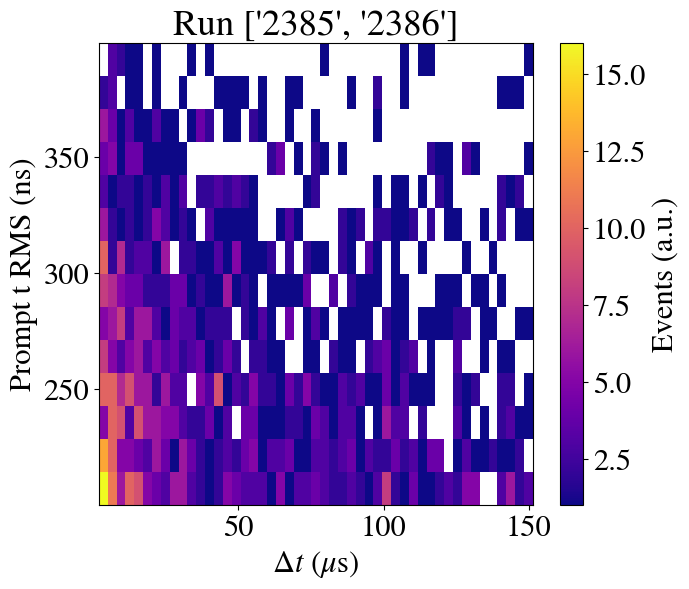

In [23]:
nhits_bins = np.linspace(df_filtered['prompt_trms'].min(), df_filtered['prompt_trms'].max(), 15)
deltaT_bins = np.linspace(2, df_filtered['DeltaT'].max(), 50)

plt.figure(figsize=(7,6))
h = plt.hist2d(df_filtered['DeltaT'],
               df_filtered['prompt_trms'],
               bins=[deltaT_bins, nhits_bins],
               cmap='plasma',
               cmin=0.0001)             # ignores cells with counts < cmin

plt.xlabel(r'$\Delta t$ ($\mu$s)')
plt.ylabel('Prompt t RMS (ns)')
plt.title(f'Run {sig_run}')
cb = plt.colorbar(h[3])
cb.set_label('Events (a.u.)')
plt.show()

In [24]:
N_events_sig, N_events_bkg

(185685, 157893)

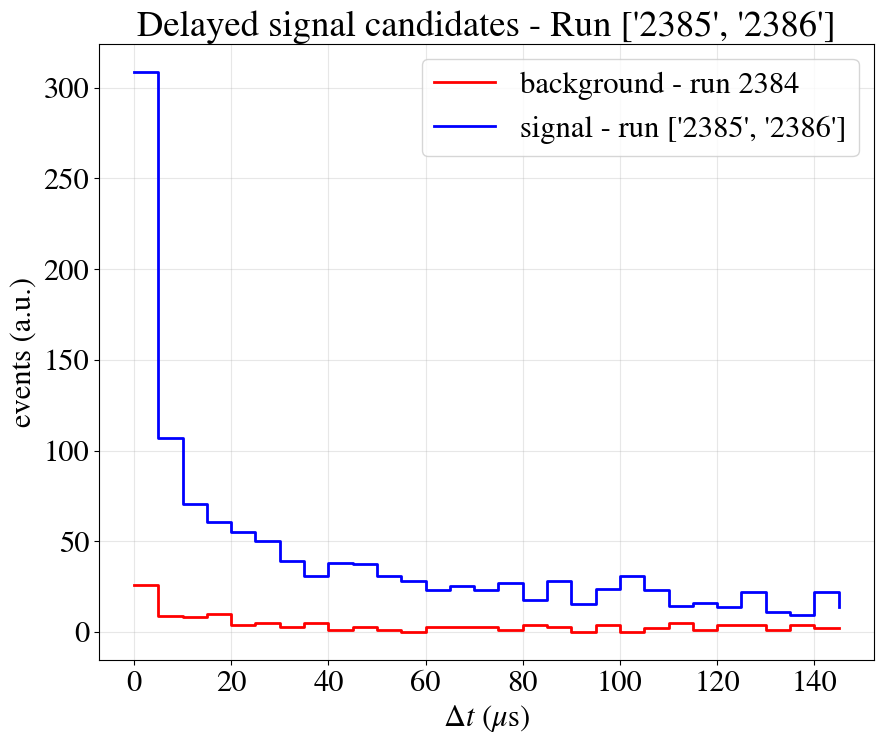

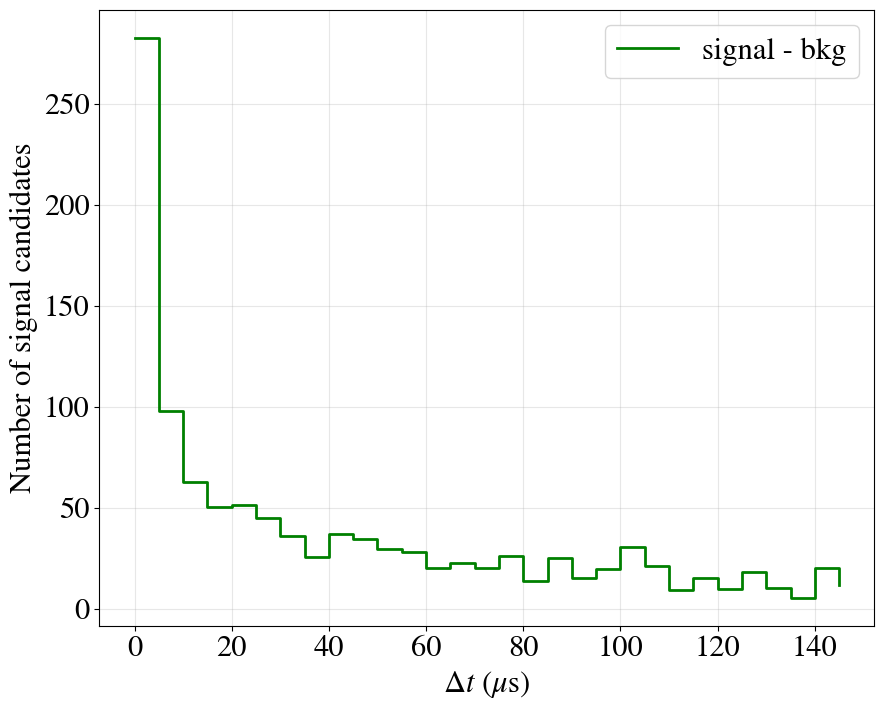

/scratch/halmazan/WCTE/ACES/jupyter_nb/candidate_plots.py:399: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x_fit, exp_func(x_fit, *popt), 'r-', label=f'Fit region: τ ≈ {tau_fit:.0f} ± {tau_err:.0f} μs', color="black")


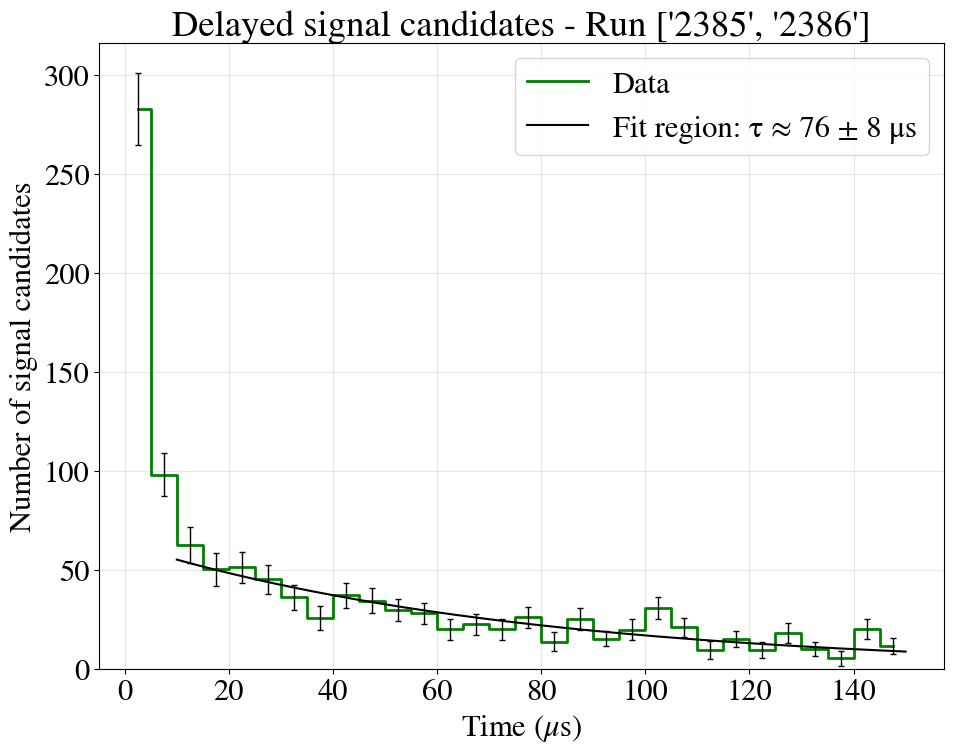

In [25]:
candidate_plots.pl_deltaT(N_events_sig, N_events_bkg, df_filtered, df_filtered_bkg, sig_run, bkg_run)

In [26]:
df_filtered['prompt_id'].nunique(), df_filtered_bkg['prompt_id'].nunique()

(1433, 122)

In [27]:
df_filtered

,prompt_id,delayed_id,prompt_nhits,prompt_time,prompt_trms,prompt_x,prompt_y,prompt_z,delayed_time,delayed_nhits,delayed_x,delayed_y,delayed_z,DeltaR,DeltaT
0,0,1,168,4.340542e+09,225.621856,-52.486267,-57.820763,33.019642,4.340661e+09,11,-257.640717,-5.536000,102.941681,290.200049,119.799382
1,1,0,182,4.366118e+09,272.685753,-239.823013,94.309608,238.848557,4.366120e+09,24,-200.640289,56.619022,91.842842,241.723003,1.500276
2,2,0,198,4.369628e+09,224.715119,106.730202,110.559296,83.451988,4.369723e+09,20,128.896469,-61.085957,-138.782364,179.083400,94.894835
3,4,0,255,4.420264e+09,258.414558,-220.527313,-133.330780,217.992126,4.420266e+09,18,257.515686,-9.749803,238.848557,372.770750,1.500848
4,5,0,185,4.423303e+09,215.388965,-103.202858,55.094444,143.439789,4.423322e+09,11,67.013031,-248.834564,-238.848557,331.388756,19.650091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1428,1756,0,175,1.345574e+12,266.609012,160.746964,-44.259621,66.928543,1.345574e+12,20,-17.799089,-18.528854,31.236534,66.869467,1.500211
1429,1757,0,151,1.345575e+12,330.691510,111.902412,-123.559036,96.227776,1.345575e+12,11,21.503605,-256.801453,-127.970863,275.517622,102.930599
1430,1759,1,158,1.345804e+12,215.877825,-30.043184,-173.318970,-186.419388,1.345804e+12,11,-144.423355,52.368881,7.783207,158.323116,51.752642
1431,1760,0,195,1.345821e+12,247.079598,-137.899429,61.357273,89.869972,1.345821e+12,18,60.208515,-250.567993,238.848557,372.770746,100.932104


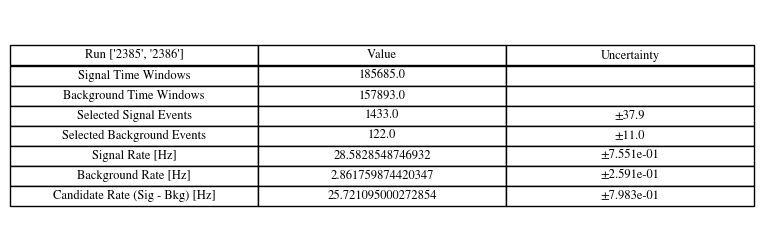

In [28]:
window_time = 270e-6  # seconds per time window

N_events_sel_sig = df_filtered['prompt_id'].nunique()
N_events_sel_bkg = df_filtered_bkg['prompt_id'].nunique()

# --- Compute rates ---
rate_sig = N_events_sel_sig / (N_events_sig * window_time)
rate_bkg = N_events_sel_bkg / (N_events_bkg * window_time)
rate_diff = rate_sig - rate_bkg

# --- Statistical uncertainties ---
# Poisson error for counts
err_N_sig = np.sqrt(N_events_sel_sig)
err_N_bkg = np.sqrt(N_events_sel_bkg)

# propagate to rates: rate = N_sel / (N_total * window_time)
err_rate_sig = err_N_sig / (N_events_sig * window_time)
err_rate_bkg = err_N_bkg / (N_events_bkg * window_time)

# difference uncertainty (assuming independence)
err_rate_diff = np.sqrt(err_rate_sig**2 + err_rate_bkg**2)

# --- Create summary table ---
results = {
    f"Run {sig_run}": [
        "Signal Time Windows",
        "Background Time Windows",
        "Selected Signal Events",
        "Selected Background Events",
        "Signal Rate [Hz]",
        "Background Rate [Hz]",
        "Candidate Rate (Sig - Bkg) [Hz]",
    ],
    "Value": [
        N_events_sig,
        N_events_bkg,
        N_events_sel_sig,
        N_events_sel_bkg,
        rate_sig,
        rate_bkg,
        rate_diff,
    ],
    "Uncertainty": [
        "",  # time windows: no Poisson error
        "",
        f"±{err_N_sig:.1f}",
        f"±{err_N_bkg:.1f}",
        f"±{err_rate_sig:.3e}",
        f"±{err_rate_bkg:.3e}",
        f"±{err_rate_diff:.3e}",
    ]
}

df_results = pd.DataFrame(results)

# Show nicely
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,3))
ax.axis('off')
tbl = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.2)

plt.show()

In [29]:
acc_file = f'/scratch/halmazan/WCTE/files/data/AmBeCandidates/accidental_candidates_{sig_run[0]}_timestest.csv'
df_acc = pd.read_csv(acc_file)

df_acc = df_acc.sort_values(['vp_prompt_time']).reset_index(drop=True)
df_acc['vp_prompt_id'] = df_acc.groupby(['vp_prompt_time'], sort=False).ngroup()
df_acc['vp_delayed_id'] = df_acc.groupby(['vp_prompt_time'], sort=False).cumcount()
cols = ['vp_prompt_id', 'vp_delayed_id'] + [col for col in df_acc.columns if col not in ['vp_prompt_id', 'vp_delayed_id']]
df_acc = df_acc[cols]

df_acc["DeltaT"] = np.abs(df_acc["vp_delayed_time"]/1000 - df_acc["vp_prompt_time"]/1000)

df_acc = df_acc[(df_acc['vp_delayed_nhits'] < 27)]
idx = df_acc.groupby(['vp_prompt_id'])['vp_delayed_id'].idxmin()
df_acc_filtered = df_acc.loc[idx].reset_index(drop=True)

df_acc_filtered

,vp_prompt_id,vp_delayed_id,vp_prompt_time,vp_delayed_time,vp_delayed_nhits,vp_delayed_x,vp_delayed_y,vp_delayed_z,DeltaT
0,0,1,4.340542e+09,4.340661e+09,11,-257.640717,-5.536000,102.941681,119.799382
1,1,1,4.343542e+09,4.343688e+09,19,4.150036,100.064690,-21.817429,146.656129
2,2,0,4.347542e+09,4.347671e+09,11,195.525177,132.609375,-238.848557,129.079598
3,3,0,4.348542e+09,4.348672e+09,13,80.826622,244.696609,238.848557,130.263902
4,4,1,4.366118e+09,4.366120e+09,24,-200.640289,56.619022,91.842842,1.500276
...,...,...,...,...,...,...,...,...,...
2447,2763,0,3.600684e+11,3.600686e+11,13,37.971062,206.517441,-75.971542,139.223134
2448,2764,0,3.600694e+11,3.600696e+11,14,251.286331,57.136375,63.073013,123.633099
2449,2765,0,3.600724e+11,3.600725e+11,11,-200.843811,80.053108,74.679146,51.580913
2450,2766,0,3.600744e+11,3.600745e+11,11,41.352814,-52.877892,135.597214,49.144995


In [64]:
df

,prompt_id,delayed_id,prompt_nhits,prompt_time,prompt_trms,prompt_x,prompt_y,prompt_z,delayed_time,delayed_nhits,delayed_x,delayed_y,delayed_z,DeltaR,DeltaT
1,0,1,168,4.340542e+09,225.621856,-52.486267,-57.820763,33.019642,4.340661e+09,11,-257.640717,-5.536000,102.941681,290.200049,119.799382
2,1,0,182,4.366118e+09,272.685753,-239.823013,94.309608,238.848557,4.366120e+09,24,-200.640289,56.619022,91.842842,241.723003,1.500276
5,2,0,198,4.369628e+09,224.715119,106.730202,110.559296,83.451988,4.369723e+09,20,128.896469,-61.085957,-138.782364,179.083400,94.894835
7,4,0,255,4.420264e+09,258.414558,-220.527313,-133.330780,217.992126,4.420266e+09,18,257.515686,-9.749803,238.848557,372.770750,1.500848
8,5,0,185,4.423303e+09,215.388965,-103.202858,55.094444,143.439789,4.423322e+09,11,67.013031,-248.834564,-238.848557,331.388756,19.650091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6569,1757,1,151,1.345575e+12,330.691510,111.902412,-123.559036,96.227776,1.345575e+12,22,39.469021,38.259827,109.850037,150.730723,147.414826
6572,1759,1,158,1.345804e+12,215.877825,-30.043184,-173.318970,-186.419388,1.345804e+12,11,-144.423355,52.368881,7.783207,158.323116,51.752642
6573,1760,0,195,1.345821e+12,247.079598,-137.899429,61.357273,89.869972,1.345821e+12,18,60.208515,-250.567993,238.848557,372.770746,100.932104
6576,1763,0,228,1.345936e+12,212.588350,-175.303589,125.710449,179.607178,1.345936e+12,17,-80.769676,155.726608,36.335182,187.727086,5.500977


In [30]:
def pl_delayed_vp(N_events_bkg, N_events_sig, df, df_bkg, sig_run, bkg_run, delayed_nhits_min, delayed_nhits_max):
    prompt_nhits = df.delayed_nhits.values
    prompt_nhits_bkg = df_bkg.vp_delayed_nhits.values

    hist, bins_edges = np.histogram(prompt_nhits_bkg, bins=20, range=(delayed_nhits_min, delayed_nhits_max))
    hist_sig, _ = np.histogram(prompt_nhits, bins = bins_edges)

    plt.figure()
    plt.step(bins_edges[:-1], hist, where='post', label=f'background - run {bkg_run}', color='red', lw=2)
    plt.step(bins_edges[:-1], hist_sig * N_events_bkg * 10/ N_events_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2, linestyle='--') 
    plt.xlabel('nHits')
    plt.ylabel('events (a.u.)')
    plt.title('Delayed signal candidates')
    plt.legend()
    plt.grid(alpha=0.3)

    nhits_bins = np.linspace(df['delayed_nhits'].min(), df['delayed_nhits'].max(), 10)
    deltaT_bins = np.linspace(df['DeltaT'].min(), df['DeltaT'].max(), 10)
    hist, xedges, yedges = np.histogram2d(df['DeltaT'], df['delayed_nhits'], bins=[deltaT_bins, nhits_bins])

    plt.figure(figsize=(7,6))
    plt.imshow(hist.T, origin='lower', aspect='auto',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            cmap='plasma')

    plt.xlabel(r'$\Delta t$ ($\mu$s)')
    plt.ylabel('nHits')
    plt.title(f'Run {sig_run}')

    cb = plt.colorbar()
    cb.set_label('Events (a.u.)')
    plt.show()

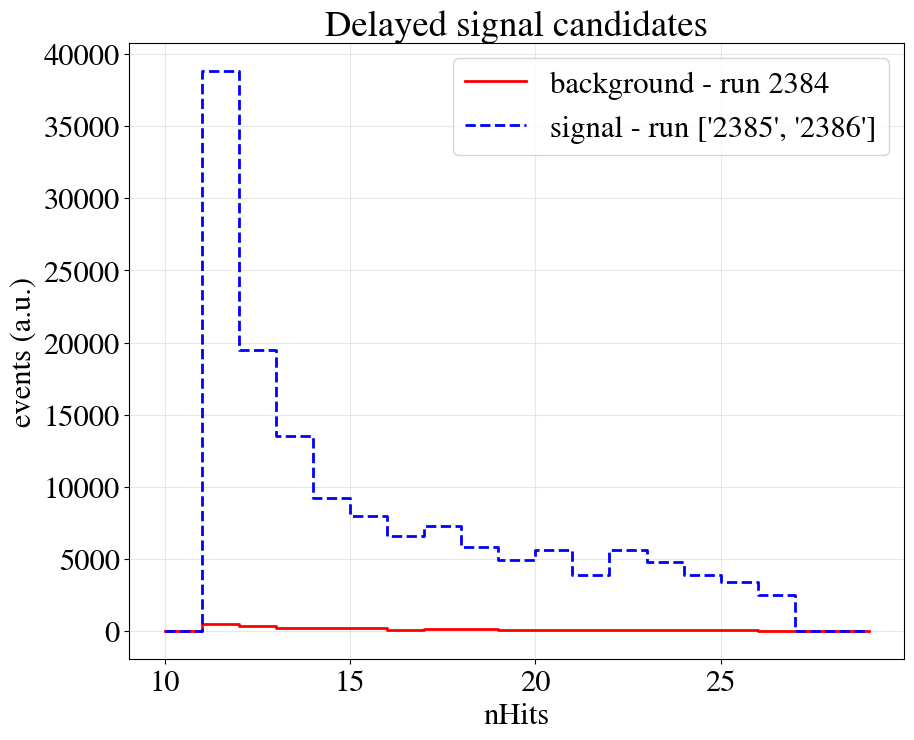

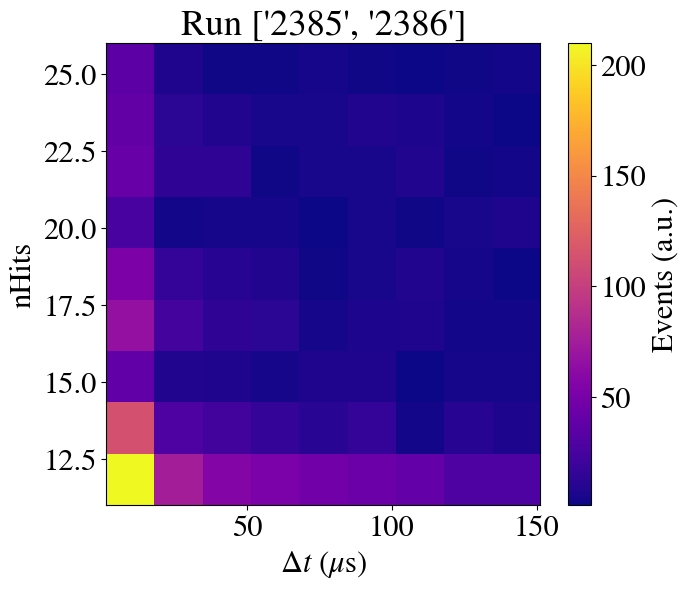

In [66]:
pl_delayed_vp(N_events_sig*10, N_events_sig, df_filtered, df_acc_filtered, sig_run, bkg_run, delayed_nhits_min, delayed_nhits_max)

In [34]:
df_filtered

,prompt_id,delayed_id,prompt_nhits,prompt_time,prompt_trms,prompt_x,prompt_y,prompt_z,delayed_time,delayed_nhits,delayed_x,delayed_y,delayed_z,DeltaR,DeltaT
0,0,1,168,4.340542e+09,225.621856,-52.486267,-57.820763,33.019642,4.340661e+09,11,-257.640717,-5.536000,102.941681,290.200049,119.799382
1,1,0,182,4.366118e+09,272.685753,-239.823013,94.309608,238.848557,4.366120e+09,24,-200.640289,56.619022,91.842842,241.723003,1.500276
2,2,0,198,4.369628e+09,224.715119,106.730202,110.559296,83.451988,4.369723e+09,20,128.896469,-61.085957,-138.782364,179.083400,94.894835
3,4,0,255,4.420264e+09,258.414558,-220.527313,-133.330780,217.992126,4.420266e+09,18,257.515686,-9.749803,238.848557,372.770750,1.500848
4,5,0,185,4.423303e+09,215.388965,-103.202858,55.094444,143.439789,4.423322e+09,11,67.013031,-248.834564,-238.848557,331.388756,19.650091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1428,1756,0,175,1.345574e+12,266.609012,160.746964,-44.259621,66.928543,1.345574e+12,20,-17.799089,-18.528854,31.236534,66.869467,1.500211
1429,1757,0,151,1.345575e+12,330.691510,111.902412,-123.559036,96.227776,1.345575e+12,11,21.503605,-256.801453,-127.970863,275.517622,102.930599
1430,1759,1,158,1.345804e+12,215.877825,-30.043184,-173.318970,-186.419388,1.345804e+12,11,-144.423355,52.368881,7.783207,158.323116,51.752642
1431,1760,0,195,1.345821e+12,247.079598,-137.899429,61.357273,89.869972,1.345821e+12,18,60.208515,-250.567993,238.848557,372.770746,100.932104


In [44]:
df_acc_filtered

,vp_prompt_id,vp_delayed_id,vp_prompt_time,vp_delayed_time,vp_delayed_nhits,vp_delayed_x,vp_delayed_y,vp_delayed_z,DeltaT
0,0,1,4.340542e+09,4.340661e+09,11,-257.640717,-5.536000,102.941681,119.799382
1,1,1,4.343542e+09,4.343688e+09,19,4.150036,100.064690,-21.817429,146.656129
2,2,0,4.347542e+09,4.347671e+09,11,195.525177,132.609375,-238.848557,129.079598
3,3,0,4.348542e+09,4.348672e+09,13,80.826622,244.696609,238.848557,130.263902
4,4,1,4.366118e+09,4.366120e+09,24,-200.640289,56.619022,91.842842,1.500276
...,...,...,...,...,...,...,...,...,...
2447,2763,0,3.600684e+11,3.600686e+11,13,37.971062,206.517441,-75.971542,139.223134
2448,2764,0,3.600694e+11,3.600696e+11,14,251.286331,57.136375,63.073013,123.633099
2449,2765,0,3.600724e+11,3.600725e+11,11,-200.843811,80.053108,74.679146,51.580913
2450,2766,0,3.600744e+11,3.600745e+11,11,41.352814,-52.877892,135.597214,49.144995


In [51]:
def exp_func(x, A, tau):
    return A * np.exp(-x / tau)

def pl_deltaT(N_events_sig, N_events_bkg, df, df_bkg, sig_run, bkg_run):
    prompt_nhits = df.DeltaT.values
    prompt_nhits_bkg = df_bkg.DeltaT.values

    hist, bins_edges = np.histogram(prompt_nhits_bkg, bins=30, range=(0, 150))
    hist_sig, _ = np.histogram(prompt_nhits, bins = bins_edges)

    s_bkg = df_bkg[df_bkg.DeltaT >100].vp_prompt_id.nunique()
    s_sig = df[df.DeltaT >100].prompt_id.nunique()

    plt.figure()
    plt.step(bins_edges[:-1], hist, where='post', label=f'background - run {bkg_run}', color='red', lw=2)
    plt.step(bins_edges[:-1], hist_sig * s_bkg / s_sig, where='post', label=f'signal - run {sig_run}', color='blue', lw=2)
    plt.xlabel(r'$\Delta t$ ($\mu$s)')
    plt.ylabel('events (a.u.)')
    plt.title(f'Delayed signal candidates - Run {sig_run}')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.figure()
    plt.step(bins_edges[:-1], hist_sig* s_bkg / s_sig - hist, where='post', linewidth=2, color='green', label=f'signal - bkg')
    plt.xlabel(r'$\Delta t$ ($\mu$s)')
    plt.ylabel('Number of signal candidates')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    bin_centers = 0.5 * (bins_edges[:-1] + bins_edges[1:])
    values = hist_sig * s_bkg / s_sig - hist

    np.savez(f'/scratch/halmazan/WCTE/files/data/AmBeCandidates/histograms_run{sig_run}.npz', deltat=values, bins_deltat=bin_centers)

    # Prepare bin centers and data for full plot
    bin_centers = (bins_edges[:-1] + bins_edges[1:]) / 2  
    data = hist_sig * s_bkg / s_sig - hist
    errors = np.sqrt(hist_sig * s_bkg / s_sig + hist)

    fit_min = 10
    fit_max = 150
    # Mask for fit region
    region_mask = (bin_centers >= fit_min) & (bin_centers <= fit_max)
    fit_x = bin_centers[region_mask]
    fit_y = data[region_mask]

    # Fit only in region
    popt, pcov = curve_fit(exp_func, fit_x, fit_y, p0=(max(fit_y), 500))
    A_fit, tau_fit = popt
    A_err, tau_err = np.sqrt(np.diag(pcov))

    # Plot: full data, fit only in region
    plt.figure()
    plt.step(bin_centers, data, where='mid', linewidth=2, label='Data', color='green')
    plt.errorbar(bin_centers, data, yerr=errors, fmt='none', ecolor='black', elinewidth=1, capsize=2)

    # Overlay fit on selected region only
    x_fit = np.linspace(fit_min, fit_max, 500)
    plt.plot(x_fit, exp_func(x_fit, *popt), 'r-', label=f'Fit region: τ ≈ {tau_fit:.0f} ± {tau_err:.0f} μs', color="black")

    plt.xlabel(r'Time ($\mu$s)')
    plt.ylabel('Number of signal candidates')
    plt.grid(alpha=0.3)
    plt.title(f'Delayed signal candidates - Run {sig_run}')
    plt.legend()
    plt.tight_layout()
    plt.ylim(bottom=0)
    plt.show()

In [74]:
df_acc_filtered.vp_prompt_id.nunique(),75703

(2452, 75703)

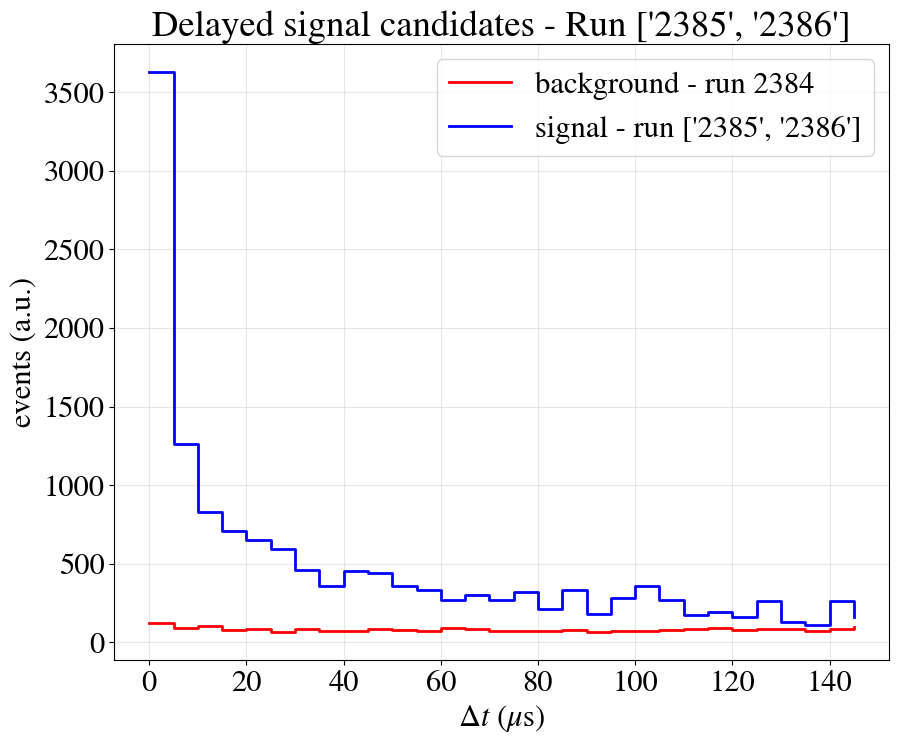

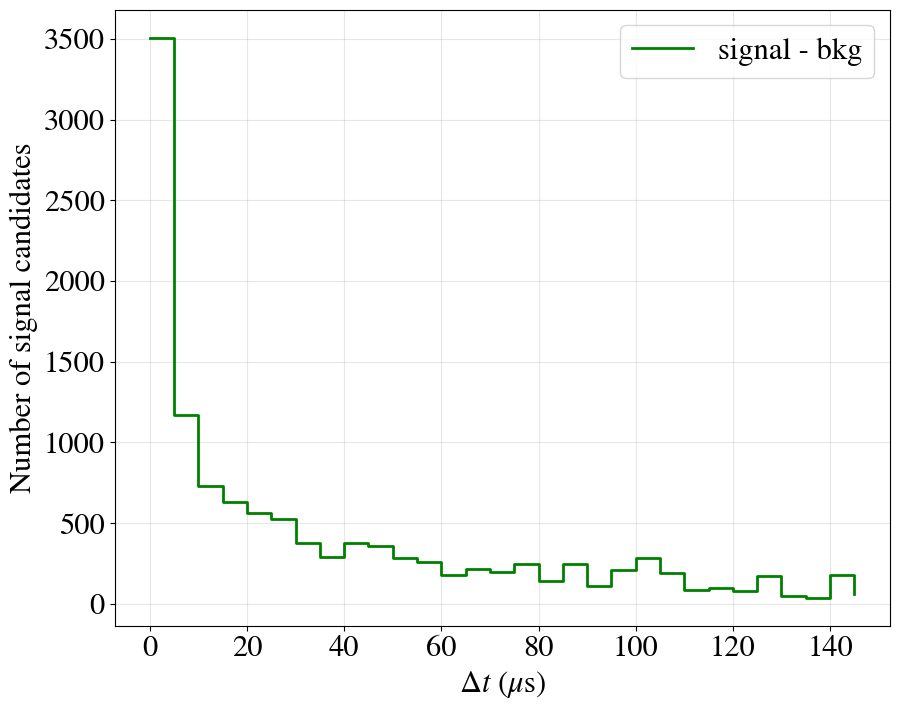

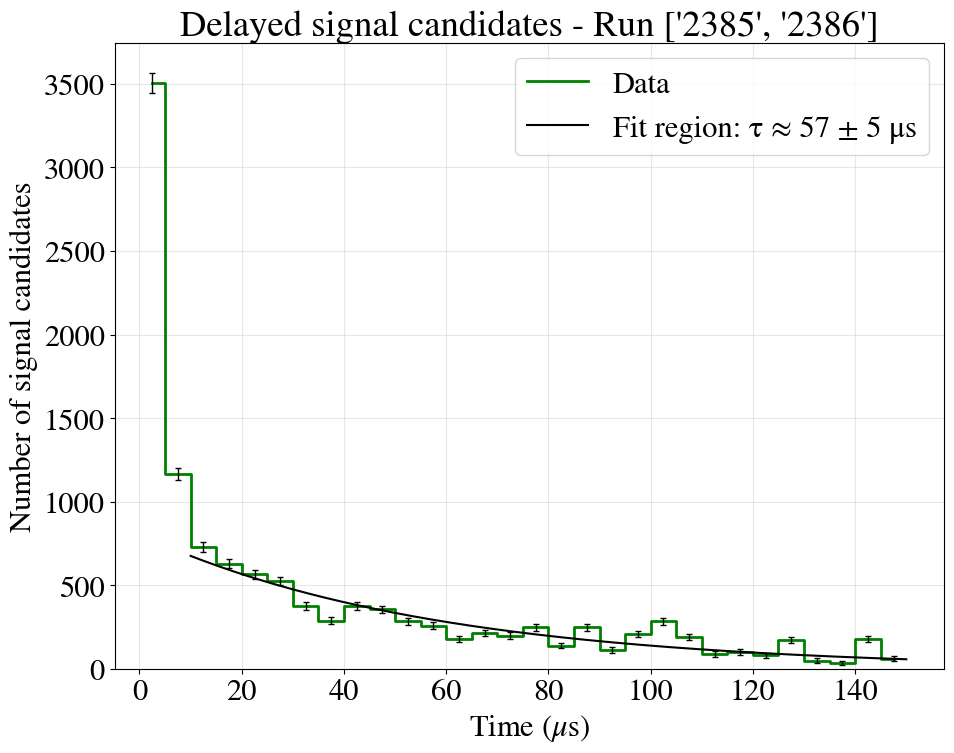

In [73]:
candidate_plots.pl_deltaT(N_events_sig, N_events_sig*10, df_filtered, df_acc_filtered, sig_run, bkg_run)